# 🏨 Gran Canaria – Accommodation Density with H3 Hex-Grids

This notebook analyzes the spatial density of **hotels, apartments, B&Bs, resorts and similar accommodation** on Gran Canaria using:

- **Overture Maps** (theme=places) as data source
- **DuckDB** for efficient cloud-native queries with predicate pushdown
- **H3** (Uber's hexagonal grid system) for density aggregation
- **Folium** and **lonboard** for interactive visualization

<a target="_blank" href="https://colab.research.google.com/github/kartAI/skygeo/blob/main/src/skygeo-workshop/gran_canaria_accommodation_density.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

---
### Overture Maps accommodation categories used

| Category | Code |
|---|---|
| Hotel | `hotel` |
| Bed & Breakfast | `bed_and_breakfast` |
| Hostel | `hostel` |
| Motel | `motel` |
| Resort | `resort` |
| Beach resort | `beach_resort` |
| Guest house | `guest_house` |
| Inn | `inn` |
| Lodge | `lodge` |
| Cottage | `cottage` |
| Holiday rental home | `holiday_rental_home` |
| Service apartments | `service_apartments` |
| Self-catering accommodation | `self_catering_accommodation` |
| Apartments | `apartments` |
| Campground | `campground` |
| RV park | `rv_park` |
| Country house | `country_house` |
| Cabin | `cabin` |

## ⚙️ 1. Setup – install and import packages

In [1]:
%%capture
%pip install duckdb geopandas h3 folium lonboard matplotlib mapclassify shapely fsspec

In [2]:
import os
import duckdb
import geopandas as gpd
import pandas as pd
import h3
import folium
import json
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from shapely.geometry import shape, mapping, Polygon

os.makedirs('./tmp', exist_ok=True)

print(f"DuckDB version: {duckdb.__version__}")
print(f"H3 version: {h3.__version__}")

DuckDB version: 1.4.4
H3 version: 4.4.2


## ☁️ 2. Initialize DuckDB with spatial + S3 support

In [3]:
conn = duckdb.connect(':memory:')
conn.execute("INSTALL spatial; LOAD spatial;")
conn.execute("SET s3_region='us-west-2';")
print("DuckDB ready with spatial extension and S3 configured.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

DuckDB ready with spatial extension and S3 configured.


## 🗺️ 3. Define the Gran Canaria study area

Gran Canaria bounding box (WGS84):
- `xmin=-15.85, ymin=27.70, xmax=-15.35, ymax=28.20`

In [4]:
# Gran Canaria bounding box [xmin, ymin, xmax, ymax]
bbox = [-15.85, 27.70, -15.35, 28.20]
xmin, ymin, xmax, ymax = bbox

print(f"Study area: xmin={xmin}, ymin={ymin}, xmax={xmax}, ymax={ymax}")

# Quick preview of the bounding box
bbox_poly = Polygon([
    (xmin, ymin), (xmax, ymin), (xmax, ymax), (xmin, ymax), (xmin, ymin)
])
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_poly], crs="EPSG:4326")
bbox_gdf.explore(color="red", style_kwds={"fillOpacity": 0.1})

Study area: xmin=-15.85, ymin=27.7, xmax=-15.35, ymax=28.2


## 🔍 4. Query Overture Maps – fetch all accommodation places

We use **Hive partitioning** and **bbox predicate pushdown** to efficiently query only the relevant geographic partition from the Overture Maps S3 dataset (terabytes in total, only kilobytes fetched).

In [5]:
# All accommodation categories from Overture Maps schema
accommodation_categories = [
    'hotel',
    'bed_and_breakfast',
    'hostel',
    'motel',
    'resort',
    'beach_resort',
    'guest_house',
    'inn',
    'lodge',
    'cottage',
    'holiday_rental_home',
    'service_apartments',
    'self_catering_accommodation',
    'apartments',
    'campground',
    'rv_park',
    'country_house',
    'cabin',
]

categories_sql = ', '.join(f"'{c}'" for c in accommodation_categories)

query = f"""
SELECT
    id,
    names.primary                      AS name,
    confidence,
    categories.primary                 AS category,
    CAST(categories AS JSON)           AS categories_json,
    ST_X(geometry)                     AS lon,
    ST_Y(geometry)                     AS lat,
    geometry
FROM
    read_parquet(
        's3://overturemaps-us-west-2/release/2026-02-18.0/theme=places/type=place/*',
        filename=true,
        hive_partitioning=1
    )
WHERE
    categories.primary IN ({categories_sql})
    AND bbox.xmin BETWEEN {xmin} AND {xmax}
    AND bbox.ymin BETWEEN {ymin} AND {ymax}
"""

print("Querying Overture Maps S3 – this may take ~30–60 seconds...")
result = conn.sql(query)
df_raw = result.df()

print(f"\nFound {len(df_raw)} accommodation places in Gran Canaria.")
df_raw.head()

Querying Overture Maps S3 – this may take ~30–60 seconds...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Found 1703 accommodation places in Gran Canaria.


,id,name,confidence,category,categories_json,lon,lat,geometry
0,5998f028-326d-4881-b626-b22cb808e4e0,BELVILLA (ES-35107-01) Preciosa casa de vacaci...,0.770000,holiday_rental_home,"{""primary"":""holiday_rental_home"",""alternate"":n...",-15.458942,27.799081,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
1,407f6df5-22af-4ce2-9968-b8f18ec80593,Apartamentos Castillo Mar,0.950063,holiday_rental_home,"{""primary"":""holiday_rental_home"",""alternate"":[...",-15.460070,27.799236,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
2,4ec97d39-6348-47fd-82d4-e5d20c9c3ddf,Apartamentos BLUE EYES,0.950063,holiday_rental_home,"{""primary"":""holiday_rental_home"",""alternate"":[...",-15.459687,27.799101,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
3,215d99c0-30bd-45ad-ba84-7221171c540b,The Safe Point Suites Castillo,0.323479,hotel,"{""primary"":""hotel"",""alternate"":[""accommodation...",-15.456349,27.800407,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
4,1f114154-62be-47e8-abe0-1faa7163906d,Seven Islands Apart B&B Nautilus,0.323479,hotel,"{""primary"":""hotel"",""alternate"":[""motel"",""accom...",-15.390805,27.859921,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."


## 💾 5. Save results to local parquet and create GeoDataFrame

In [6]:
# Register and export to parquet
conn.register('accommodation_raw', df_raw)
conn.execute("""
    COPY (
        SELECT id, name, confidence, category, categories_json, lon, lat
        FROM accommodation_raw
    ) TO './tmp/gran_canaria_accommodation.parquet' (FORMAT PARQUET)
""")
print("Saved to ./tmp/gran_canaria_accommodation.parquet")

Saved to ./tmp/gran_canaria_accommodation.parquet


## 📊 6. Exploratory Data Analysis – counts per category

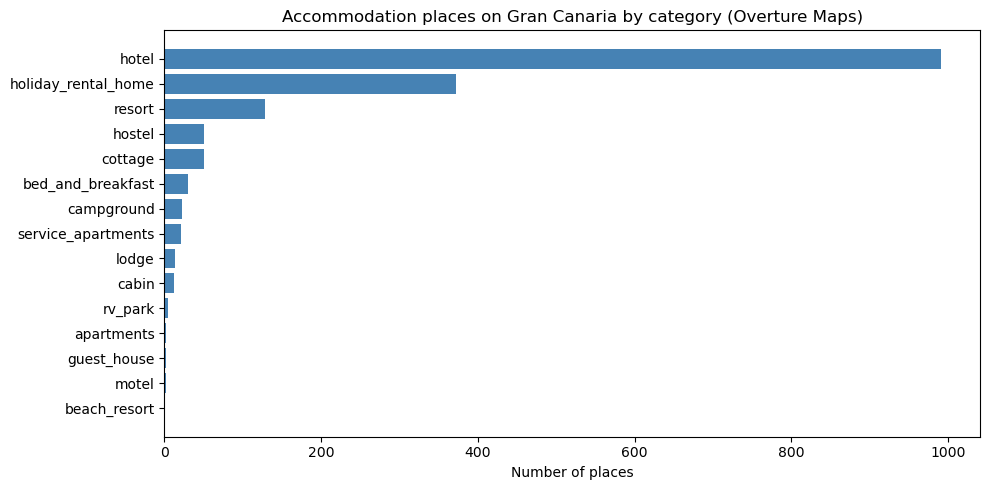

,category,count
0,hotel,991
1,holiday_rental_home,372
2,resort,128
3,hostel,51
4,cottage,51
5,bed_and_breakfast,30
6,campground,22
7,service_apartments,21
8,lodge,14
9,cabin,12


In [7]:
category_counts = df_raw.groupby('category').size().sort_values(ascending=False).reset_index()
category_counts.columns = ['category', 'count']

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(category_counts['category'], category_counts['count'], color='steelblue')
ax.set_xlabel('Number of places')
ax.set_title('Accommodation places on Gran Canaria by category (Overture Maps)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(category_counts)

## 🔷 7. Assign H3 indexes

H3 resolution guide for Gran Canaria analysis:
- **Resolution 7** (~5.2 km² / cell) – island-wide overview
- **Resolution 8** (~0.7 km² / cell) – neighborhood level ✅ recommended
- **Resolution 9** (~0.1 km² / cell) – very fine-grained

We'll work with resolution 8 as the default but add a resolution slider comparison.

In [8]:
H3_RESOLUTION = 8  # Change this to 7 or 9 to explore different granularities

# Drop rows with missing coordinates
df = df_raw.dropna(subset=['lat', 'lon']).copy()

# Assign H3 cell index
df['h3_index'] = df.apply(
    lambda row: h3.latlng_to_cell(row['lat'], row['lon'], H3_RESOLUTION),
    axis=1
)

print(f"H3 resolution: {H3_RESOLUTION}")
print(f"Number of unique H3 cells: {df['h3_index'].nunique()}")
df[['name', 'category', 'lat', 'lon', 'h3_index']].head(10)

H3 resolution: 8
Number of unique H3 cells: 348


,name,category,lat,lon,h3_index
0,BELVILLA (ES-35107-01) Preciosa casa de vacaci...,holiday_rental_home,27.799081,-15.458942,88344ca6ebfffff
1,Apartamentos Castillo Mar,holiday_rental_home,27.799236,-15.460070,88344ca6ebfffff
2,Apartamentos BLUE EYES,holiday_rental_home,27.799101,-15.459687,88344ca6ebfffff
3,The Safe Point Suites Castillo,hotel,27.800407,-15.456349,88344ca6ebfffff
4,Seven Islands Apart B&B Nautilus,hotel,27.859921,-15.390805,88346b695dfffff
5,J Holiday,hotel,27.856185,-15.391190,88346b695dfffff
6,Grancanariarent Playa de Arinaga,hotel,27.856966,-15.397188,88346b6943fffff
7,Casa Daura Playa de Arinaga,holiday_rental_home,27.856161,-15.394159,88346b695dfffff
8,Hotel Playa de Arinaga,hotel,27.857294,-15.395650,88346b695dfffff
9,Casa Mar Azul,hotel,27.857806,-15.396479,88346b6943fffff


## 🔢 8. Aggregate density per H3 cell

In [9]:
# Total count per H3 cell
hex_density = df.groupby('h3_index').size().reset_index(name='total_count')

# Category breakdown per H3 cell (pivot)
category_pivot = (
    df.groupby(['h3_index', 'category'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

hex_density = hex_density.merge(category_pivot, on='h3_index', how='left')

# Add H3 cell center coordinates for reference
hex_density['center_lat'] = hex_density['h3_index'].apply(
    lambda x: h3.cell_to_latlng(x)[0]
)
hex_density['center_lon'] = hex_density['h3_index'].apply(
    lambda x: h3.cell_to_latlng(x)[1]
)

print(f"Density table: {len(hex_density)} cells")
display(hex_density.sort_values('total_count', ascending=False).head(10))

Density table: 348 cells


,h3_index,total_count,apartments,beach_resort,bed_and_breakfast,cabin,campground,cottage,guest_house,holiday_rental_home,hostel,hotel,lodge,motel,resort,rv_park,service_apartments,center_lat,center_lon
282,88346b4c49fffff,94,0,0,2,0,0,1,0,27,6,53,1,0,2,0,2,28.140674,-15.432785
37,88344ca517fffff,75,0,0,1,0,1,0,0,11,0,51,0,1,8,0,2,27.762539,-15.572019
55,88344ca5edfffff,64,0,0,1,1,0,1,2,5,1,42,0,0,9,0,2,27.754805,-15.577094
54,88344ca5e9fffff,60,0,0,0,1,0,0,0,13,0,36,0,0,7,1,2,27.754890,-15.567093
35,88344ca513fffff,56,0,0,0,0,0,1,0,8,0,42,0,0,5,0,0,27.762623,-15.562017
106,88344caf55fffff,48,0,0,0,0,0,0,0,11,0,33,0,0,2,0,2,27.792056,-15.711841
325,88346b4e23fffff,47,0,0,0,0,0,1,0,9,2,32,1,0,2,0,0,28.148408,-15.427678
43,88344ca533fffff,45,0,0,0,0,0,0,0,6,0,28,0,0,10,0,1,27.754719,-15.587095
47,88344ca53bfffff,44,0,0,0,0,0,1,0,9,1,29,0,1,3,0,0,27.762453,-15.582021
107,88344caf57fffff,40,1,1,0,0,0,0,0,8,0,27,0,0,1,0,2,27.784409,-15.706898


## 🗺️ 9. Convert H3 cells to GeoDataFrame polygons

In [10]:
def h3_to_polygon(h3_index):
    """Convert an H3 cell index to a Shapely Polygon."""
    boundary = h3.cell_to_boundary(h3_index)  # list of (lat, lon) tuples
    # h3 returns (lat, lon), shapely expects (lon, lat)
    return Polygon([(lon, lat) for lat, lon in boundary])

hex_density['geometry'] = hex_density['h3_index'].apply(h3_to_polygon)

gdf_hex = gpd.GeoDataFrame(hex_density, geometry='geometry', crs='EPSG:4326')

print(f"GeoDataFrame created with {len(gdf_hex)} hex cells.")
gdf_hex[['h3_index', 'total_count', 'geometry']].head()

GeoDataFrame created with 348 hex cells.


,h3_index,total_count,geometry
0,88344c8497fffff,1,"POLYGON ((-15.70942 28.08978, -15.71446 28.087..."
1,88344c8499fffff,10,"POLYGON ((-15.69925 28.10527, -15.70429 28.102..."
2,88344c849dfffff,6,"POLYGON ((-15.70929 28.10519, -15.71434 28.102..."
3,88344c84d7fffff,6,"POLYGON ((-15.70421 28.11294, -15.70925 28.110..."
4,88344c8687fffff,3,"POLYGON ((-15.69377 28.15926, -15.69882 28.156..."


## 🎨 10. Visualize – H3 Hex Density Choropleth Map

In [11]:
# Build tooltip fields (only include category columns that exist in data)
known_categories = [
    'hotel', 'bed_and_breakfast', 'hostel', 'motel', 'resort', 'beach_resort',
    'guest_house', 'inn', 'lodge', 'cottage', 'holiday_rental_home',
    'service_apartments', 'self_catering_accommodation', 'apartments',
    'campground', 'rv_park', 'country_house', 'cabin'
]
tooltip_cats = [c for c in known_categories if c in gdf_hex.columns]
tooltip_fields = ['total_count', 'h3_index'] + tooltip_cats
tooltip_aliases = ['Total', 'H3 cell'] + tooltip_cats

# Center map on Gran Canaria
center_lat = (ymin + ymax) / 2
center_lon = (xmin + xmax) / 2

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles='CartoDB positron'
)

# Choropleth using log scale for better color distribution
folium.Choropleth(
    geo_data=gdf_hex[['h3_index', 'total_count', 'geometry']].to_json(),
    name='Accommodation density',
    data=gdf_hex[['h3_index', 'total_count']],
    columns=['h3_index', 'total_count'],
    key_on='feature.properties.h3_index',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name=f'Accommodation places per H3 cell (resolution {H3_RESOLUTION})',
    nan_fill_color='transparent',
).add_to(m)

# Add tooltip layer with category breakdown
folium.GeoJson(
    data=gdf_hex.to_json(),
    name='Detail tooltip',
    style_function=lambda x: {'fillOpacity': 0, 'weight': 0},
    tooltip=folium.GeoJsonTooltip(
        fields=tooltip_fields,
        aliases=tooltip_aliases,
        localize=True,
    )
).add_to(m)

folium.LayerControl().add_to(m)
m

## 🏨 vs 🏠 11. Hotel density vs. Apartment/rental density – side-by-side comparison

Hotels represent **commercial lodging**, while apartments and holiday rentals represent **short-term rental market** (Airbnb-style).

In [12]:
hotel_categories = ['hotel', 'motel', 'resort', 'beach_resort', 'inn', 'lodge', 'hostel']
rental_categories = [
    'apartments', 'holiday_rental_home', 'service_apartments',
    'self_catering_accommodation', 'cottage', 'country_house', 'cabin', 'guest_house'
]

# Sum counts for each group (only columns that exist)
existing_hotel = [c for c in hotel_categories if c in gdf_hex.columns]
existing_rental = [c for c in rental_categories if c in gdf_hex.columns]

gdf_hex['hotel_count'] = gdf_hex[existing_hotel].sum(axis=1) if existing_hotel else 0
gdf_hex['rental_count'] = gdf_hex[existing_rental].sum(axis=1) if existing_rental else 0

print(f"Hotel-type places:  {gdf_hex['hotel_count'].sum():.0f}")
print(f"Rental-type places: {gdf_hex['rental_count'].sum():.0f}")

Hotel-type places:  1187
Rental-type places: 460


In [13]:
def make_density_map(gdf, count_col, title, color='YlOrRd'):
    """Create a folium choropleth map for a given count column."""
    center_lat = (ymin + ymax) / 2
    center_lon = (xmin + xmax) / 2
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=11,
        tiles='CartoDB positron'
    )
    filtered = gdf[gdf[count_col] > 0]
    folium.Choropleth(
        geo_data=filtered[['h3_index', count_col, 'geometry']].to_json(),
        name=title,
        data=filtered[['h3_index', count_col]],
        columns=['h3_index', count_col],
        key_on='feature.properties.h3_index',
        fill_color=color,
        fill_opacity=0.7,
        line_opacity=0.2,
        legend_name=title,
        nan_fill_color='transparent',
    ).add_to(m)
    folium.GeoJson(
        data=filtered.to_json(),
        style_function=lambda x: {'fillOpacity': 0, 'weight': 0},
        tooltip=folium.GeoJsonTooltip(fields=['h3_index', count_col], aliases=['H3 cell', 'Count'])
    ).add_to(m)
    return m

print("Hotels map:")
make_density_map(gdf_hex, 'hotel_count', f'Hotel density (res {H3_RESOLUTION})', color='Blues')

Hotels map:


In [14]:
print("Rentals / apartments map:")
make_density_map(gdf_hex, 'rental_count', f'Apartment & rental density (res {H3_RESOLUTION})', color='Greens')

Rentals / apartments map:


## 🔭 12. Explore different H3 resolutions

In [15]:
def build_h3_density(df_places, resolution):
    """Build a GeoDataFrame of H3 hex density at a given resolution."""
    df_r = df_places.copy()
    df_r['h3_index'] = df_r.apply(
        lambda row: h3.latlng_to_cell(row['lat'], row['lon'], resolution), axis=1
    )
    agg = df_r.groupby('h3_index').size().reset_index(name='count')
    agg['geometry'] = agg['h3_index'].apply(h3_to_polygon)
    return gpd.GeoDataFrame(agg, geometry='geometry', crs='EPSG:4326')

# Compare resolutions 7, 8, 9
for res in [7, 8, 9]:
    gdf_r = build_h3_density(df, res)
    print(f"Resolution {res}: {len(gdf_r)} cells, max count per cell = {gdf_r['count'].max()}")

Resolution 7: 162 cells, max count per cell = 179
Resolution 8: 348 cells, max count per cell = 94
Resolution 9: 607 cells, max count per cell = 28


In [16]:
# Interactive map at resolution 9 (fine-grained)
gdf_r9 = build_h3_density(df, 9)

center_lat = (ymin + ymax) / 2
center_lon = (xmin + xmax) / 2
m9 = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles='CartoDB positron')

folium.Choropleth(
    geo_data=gdf_r9.to_json(),
    name='Density H3 res=9',
    data=gdf_r9[['h3_index', 'count']],
    columns=['h3_index', 'count'],
    key_on='feature.properties.h3_index',
    fill_color='YlOrRd',
    fill_opacity=0.75,
    line_opacity=0.1,
    legend_name='Accommodation places per H3 cell (resolution 9)',
).add_to(m9)

folium.GeoJson(
    data=gdf_r9.to_json(),
    style_function=lambda x: {'fillOpacity': 0, 'weight': 0},
    tooltip=folium.GeoJsonTooltip(fields=['h3_index', 'count'], aliases=['H3 cell', 'Count'])
).add_to(m9)

print("Fine-grained map at H3 resolution 9:")
m9

Fine-grained map at H3 resolution 9:


## 📊 13. Top 10 densest H3 cells

In [17]:
top10 = gdf_hex.sort_values('total_count', ascending=False).head(10)

display_cols = ['h3_index', 'total_count', 'center_lat', 'center_lon'] + \
               [c for c in known_categories if c in gdf_hex.columns]

display(top10[display_cols].reset_index(drop=True))

# Mark top-10 densest cells on a folium map
center_lat = (ymin + ymax) / 2
center_lon = (xmin + xmax) / 2
m_top = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles='CartoDB positron')

for _, row in top10.iterrows():
    folium.CircleMarker(
        location=[row['center_lat'], row['center_lon']],
        radius=min(20, row['total_count'] / 2),
        color='crimson',
        fill=True,
        fill_color='crimson',
        fill_opacity=0.6,
        tooltip=f"{row['total_count']} accommodation places"
    ).add_to(m_top)

m_top

,h3_index,total_count,center_lat,center_lon,hotel,bed_and_breakfast,hostel,motel,resort,beach_resort,guest_house,lodge,cottage,holiday_rental_home,service_apartments,apartments,campground,rv_park,cabin
0,88346b4c49fffff,94,28.140674,-15.432785,53,2,6,0,2,0,0,1,1,27,2,0,0,0,0
1,88344ca517fffff,75,27.762539,-15.572019,51,1,0,1,8,0,0,0,0,11,2,0,1,0,0
2,88344ca5edfffff,64,27.754805,-15.577094,42,1,1,0,9,0,2,0,1,5,2,0,0,0,1
3,88344ca5e9fffff,60,27.754890,-15.567093,36,0,0,0,7,0,0,0,0,13,2,0,0,1,1
4,88344ca513fffff,56,27.762623,-15.562017,42,0,0,0,5,0,0,0,1,8,0,0,0,0,0
5,88344caf55fffff,48,27.792056,-15.711841,33,0,0,0,2,0,0,0,0,11,2,0,0,0,0
6,88346b4e23fffff,47,28.148408,-15.427678,32,0,2,0,2,0,0,1,1,9,0,0,0,0,0
7,88344ca533fffff,45,27.754719,-15.587095,28,0,0,0,10,0,0,0,0,6,1,0,0,0,0
8,88344ca53bfffff,44,27.762453,-15.582021,29,0,1,1,3,0,0,0,1,9,0,0,0,0,0
9,88344caf57fffff,40,27.784409,-15.706898,27,0,0,0,1,1,0,0,0,8,2,1,0,0,0


## 💡 Reflection questions

1. **Where are the tourist hotspots?** Do the highest-density cells correspond to known resort areas (Playa del Inglés, Maspalomas, Las Palmas)?
2. **Hotels vs. apartments**: Is the short-term rental market (apartments, holiday homes) more dispersed or more concentrated than hotels?
3. **H3 resolution tradeoffs**: How does changing resolution from 7 → 8 → 9 affect the story the map tells?
4. **Data quality**: How confident are you in the completeness of Overture Maps data for a Spanish island? How could you cross-validate?
5. **Next steps**: Could you overlay population data, beach locations, or road networks to explain the density patterns?